# Multivariate Analysis

This notebook studies how the strongest candidate features behave together. The goal is to move beyond pairwise analysis and determine whether the highest-signal variables remain useful when considered jointly for feature selection and downstream modeling.


## 1. Objectives

This notebook focuses on the following tasks:

- build a multivariate feature set from the strongest bivariate signals
- examine correlation structure across priority features
- check whether multicollinearity remains low among the shortlisted variables
- compare correlation patterns for legitimate and fraudulent transactions
- inspect joint behavior of the strongest features in a shared feature space
- save tables, figures, and a markdown report for later modeling decisions


## Output Guide

- **Selected feature table:** shows which variables move forward from bivariate analysis into joint analysis.
- **Correlation matrix and heatmap:** show whether strong features remain complementary or become redundant when examined together.
- **High-correlation pairs table:** flags possible multicollinearity risk for linear models and feature selection.
- **Class-specific correlation outputs:** compare how feature relationships differ between legitimate and fraudulent transactions.
- **Difference heatmap:** highlights where fraud behavior changes the joint structure of the data.
- **Interaction plots:** show whether the strongest features create visible class separation when viewed together.

The purpose of these outputs is to decide which variables should move forward into feature engineering and model development.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sys.path.append(str(Path("..").resolve()))

from src.config import AMOUNT_COLUMN, PCA_COLUMNS, PROJECT_ROOT, TARGET_COLUMN, TIME_COLUMN
from src.data.data_loader import load_cleaned_data

NOTEBOOK_TABLES_DIR = PROJECT_ROOT / "reports" / "tables" / "07_multivariate_analysis"
NOTEBOOK_FIGURES_DIR = PROJECT_ROOT / "reports" / "figures" / "07_multivariate_analysis"
NOTEBOOK_TABLES_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOK_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="white")

print("Imports OK")
print(f"  Target column : {TARGET_COLUMN}")
print(f"  Tables dir    : {NOTEBOOK_TABLES_DIR}")
print(f"  Figures dir   : {NOTEBOOK_FIGURES_DIR}")


Imports OK
  Target column : Class
  Tables dir    : /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/07_multivariate_analysis
  Figures dir   : /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/figures/07_multivariate_analysis


## 2. Load Cleaned Data


In [2]:
df = load_cleaned_data()

print("Cleaned dataset shape:", df.shape)
df.head()


Cleaned dataset shape: (283726, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 3. Selected Feature Set

This section carries forward the strongest features from the bivariate stage. The top 10 PCA features are selected by absolute correlation with `Class`, and `Amount` plus `Time` are retained as contextual variables for multivariate review.


In [3]:
pca_correlations = df[[*PCA_COLUMNS, TARGET_COLUMN]].corr(numeric_only=True)[TARGET_COLUMN].drop(TARGET_COLUMN)
selected_pca_features = pca_correlations.abs().sort_values(ascending=False).head(10).index.tolist()
selected_features = selected_pca_features + [TIME_COLUMN, AMOUNT_COLUMN]

selected_feature_table = pd.DataFrame({
    "feature": selected_features,
    "feature_type": ["PCA"] * len(selected_pca_features) + ["Raw", "Raw"],
    "correlation_with_class": [pca_correlations[feature] for feature in selected_pca_features] + [
        df[[TIME_COLUMN, TARGET_COLUMN]].corr(numeric_only=True).loc[TIME_COLUMN, TARGET_COLUMN],
        df[[AMOUNT_COLUMN, TARGET_COLUMN]].corr(numeric_only=True).loc[AMOUNT_COLUMN, TARGET_COLUMN],
    ],
})
selected_feature_table["abs_correlation_with_class"] = selected_feature_table["correlation_with_class"].abs()
selected_feature_table.to_csv(NOTEBOOK_TABLES_DIR / "selected_feature_set.csv", index=False)
selected_feature_table


,feature,feature_type,correlation_with_class,abs_correlation_with_class
0,V17,PCA,-0.313498,0.313498
1,V14,PCA,-0.293375,0.293375
2,V12,PCA,-0.250711,0.250711
3,V10,PCA,-0.206971,0.206971
4,V16,PCA,-0.187186,0.187186
5,V3,PCA,-0.182322,0.182322
6,V7,PCA,-0.172347,0.172347
7,V11,PCA,0.149067,0.149067
8,V4,PCA,0.129326,0.129326
9,V18,PCA,-0.105340,0.105340


## 4. Correlation Matrix of Priority Features

The correlation matrix is used here to identify redundancy across the shortlisted variables. Because these features include PCA components, low multicollinearity is expected, but it should still be confirmed before modeling.


In [4]:
multivariate_df = df[selected_features + [TARGET_COLUMN]].copy()
multivariate_corr = multivariate_df.corr(numeric_only=True)
multivariate_corr.to_csv(NOTEBOOK_TABLES_DIR / "multivariate_correlation_matrix.csv")
multivariate_corr


,V17,V14,V12,V10,V16,V3,V7,V11,V4,V18,Time,Amount,Class
V17,1.000000,-0.013551,-0.012856,-0.007877,-0.009063,-0.008159,-0.008794,0.007353,0.003655,-0.005277,-0.073819,0.007730,-0.313498
V14,-0.013551,1.000000,-0.010007,0.000168,-0.009074,-0.003027,-0.003816,0.007713,0.002801,-0.004483,-0.100316,0.034122,-0.293375
V12,-0.012856,-0.010007,1.000000,-0.006942,-0.007372,-0.005900,-0.006153,0.005569,0.003366,-0.003464,0.125500,-0.009254,-0.250711
V10,-0.007877,0.000168,-0.006942,1.000000,-0.003715,-0.009632,-0.013617,0.000844,0.002753,-0.002450,0.031068,-0.102255,-0.206971
V16,-0.009063,-0.009074,-0.007372,-0.003715,1.000000,-0.004430,-0.005944,0.004751,0.003346,-0.005427,0.011286,-0.004488,-0.187186
V3,-0.008159,-0.003027,-0.005900,-0.009632,-0.004430,1.000000,-0.011721,0.002339,0.002829,-0.003495,-0.422054,-0.212410,-0.182322
V7,-0.008794,-0.003816,-0.006153,-0.013617,-0.005944,-0.011721,1.000000,0.002454,0.004657,-0.004279,0.085335,0.400408,-0.172347
V11,0.007353,0.007713,0.005569,0.000844,0.004751,0.002339,0.002454,1.000000,-0.001223,0.002095,-0.248536,-0.000015,0.149067
V4,0.003655,0.002801,0.003366,0.002753,0.003346,0.002829,0.004657,-0.001223,1.000000,0.002325,-0.105845,0.099514,0.129326
V18,-0.005277,-0.004483,-0.003464,-0.002450,-0.005427,-0.003495,-0.004279,0.002095,0.002325,1.000000,0.090305,0.035775,-0.105340


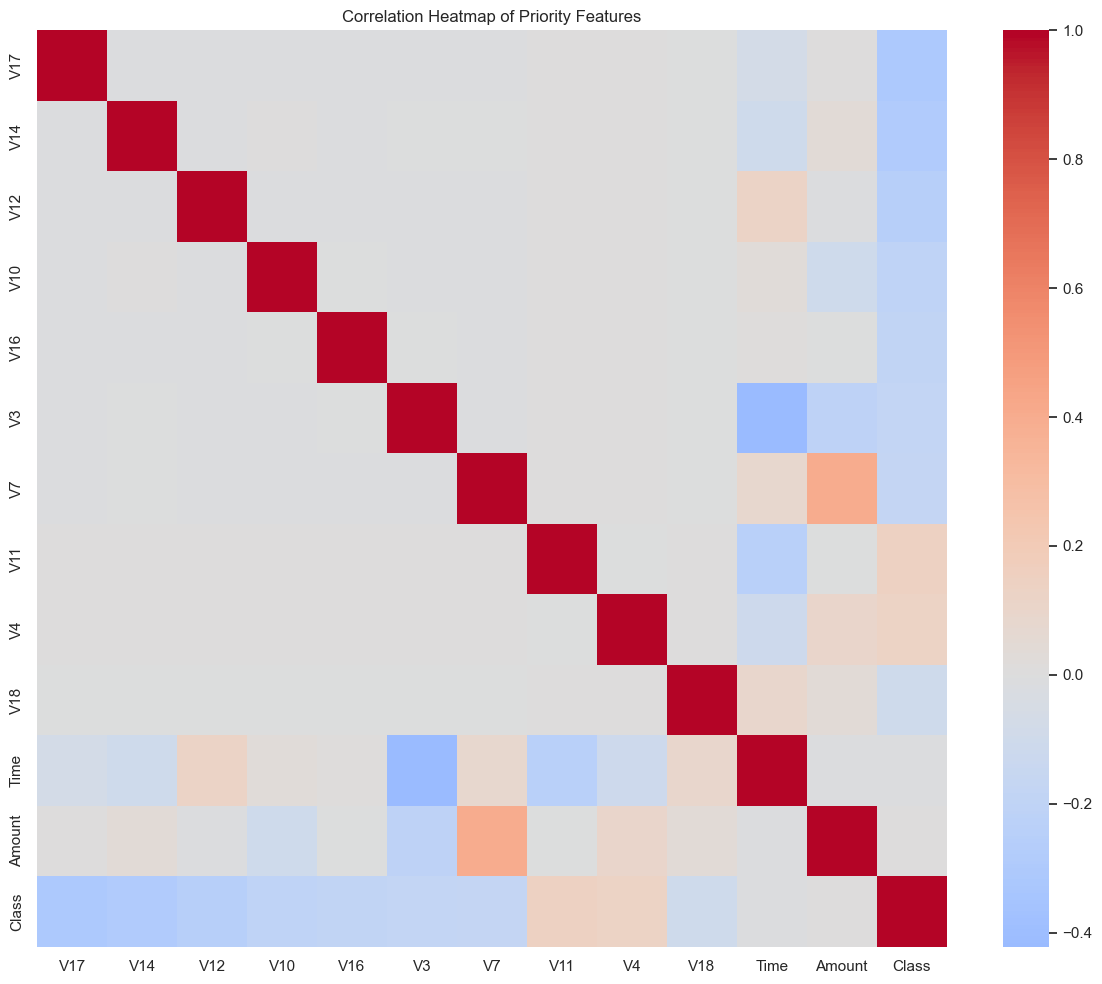

In [5]:
plt.figure(figsize=(12, 10))
sns.heatmap(multivariate_corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap of Priority Features")
plt.tight_layout()
plt.savefig(NOTEBOOK_FIGURES_DIR / "priority_feature_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


## 5. Multicollinearity Review

The following table lists feature pairs with high absolute correlation. In this project, it is mainly used to check whether any shortlisted variables are redundant enough to create instability for linear models.


In [6]:
corr_features_only = multivariate_corr.loc[selected_features, selected_features]
high_corr_rows = []
threshold = 0.70

for i, feature_a in enumerate(selected_features):
    for feature_b in selected_features[i + 1:]:
        corr_value = corr_features_only.loc[feature_a, feature_b]
        if abs(corr_value) >= threshold:
            high_corr_rows.append({
                "feature_a": feature_a,
                "feature_b": feature_b,
                "correlation": round(corr_value, 6),
                "abs_correlation": round(abs(corr_value), 6),
            })

high_corr_pairs = pd.DataFrame(high_corr_rows).sort_values("abs_correlation", ascending=False) if high_corr_rows else pd.DataFrame(columns=["feature_a", "feature_b", "correlation", "abs_correlation"])
high_corr_pairs.to_csv(NOTEBOOK_TABLES_DIR / "high_correlation_pairs.csv", index=False)
high_corr_pairs


,feature_a,feature_b,correlation,abs_correlation


## 6. Class-Specific Correlation Structure

Fraud and non-fraud transactions can show different joint behavior even when single-feature distributions look similar. Comparing class-specific correlation matrices helps reveal whether feature relationships change when fraud is present.


In [7]:
class_0_corr = df.loc[df[TARGET_COLUMN] == 0, selected_features].corr(numeric_only=True)
class_1_corr = df.loc[df[TARGET_COLUMN] == 1, selected_features].corr(numeric_only=True)
corr_difference = class_1_corr - class_0_corr

class_0_corr.to_csv(NOTEBOOK_TABLES_DIR / "class_0_correlation_matrix.csv")
class_1_corr.to_csv(NOTEBOOK_TABLES_DIR / "class_1_correlation_matrix.csv")
corr_difference.to_csv(NOTEBOOK_TABLES_DIR / "correlation_difference_matrix.csv")

print("Class 0 correlation matrix saved")
print("Class 1 correlation matrix saved")
print("Correlation difference matrix saved")


Class 0 correlation matrix saved
Class 1 correlation matrix saved
Correlation difference matrix saved


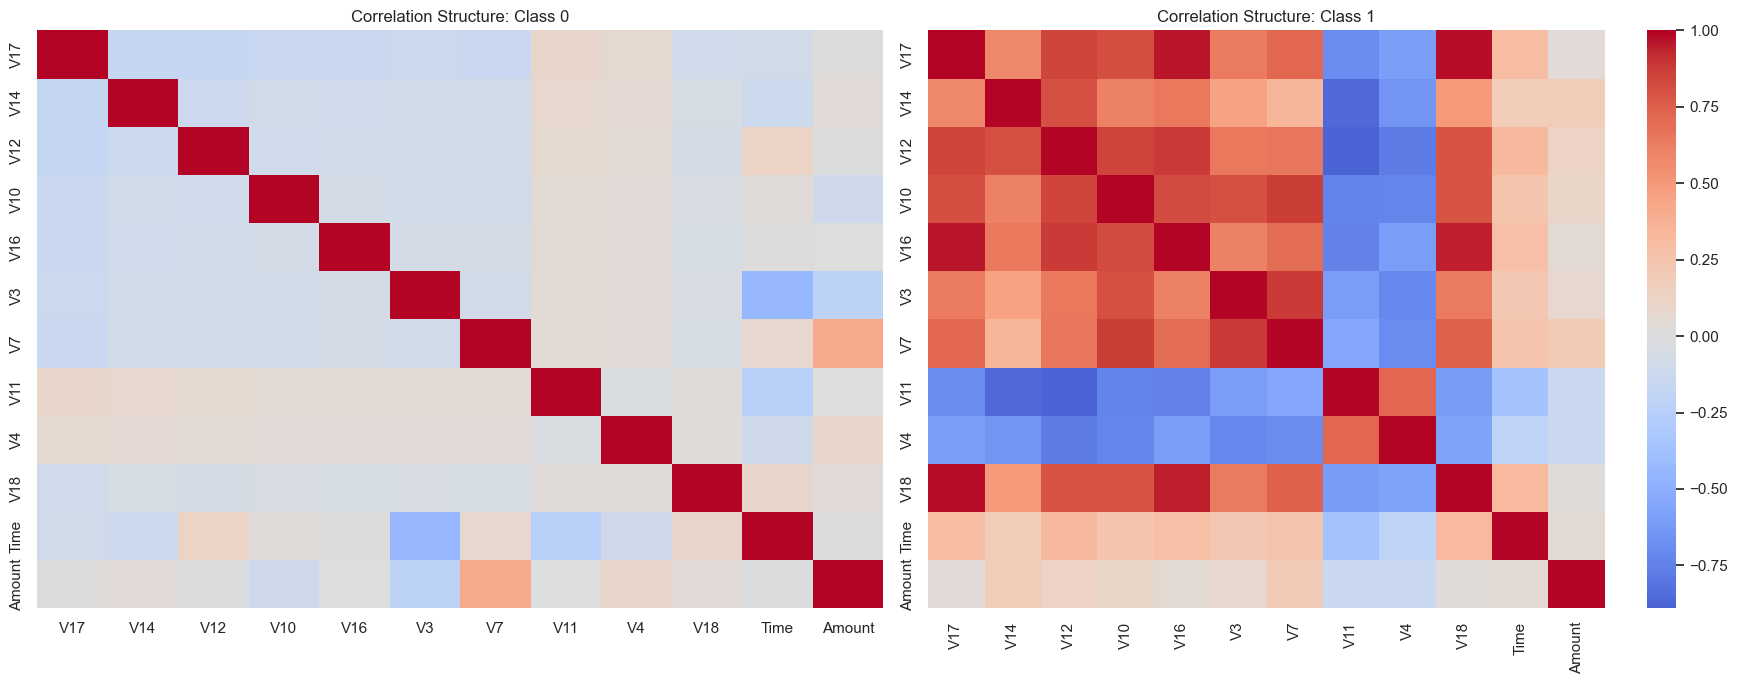

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(class_0_corr, cmap="coolwarm", center=0, ax=axes[0], cbar=False)
axes[0].set_title("Correlation Structure: Class 0")
sns.heatmap(class_1_corr, cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("Correlation Structure: Class 1")
plt.tight_layout()
plt.savefig(NOTEBOOK_FIGURES_DIR / "class_specific_correlation_heatmaps.png", dpi=300, bbox_inches="tight")
plt.show()


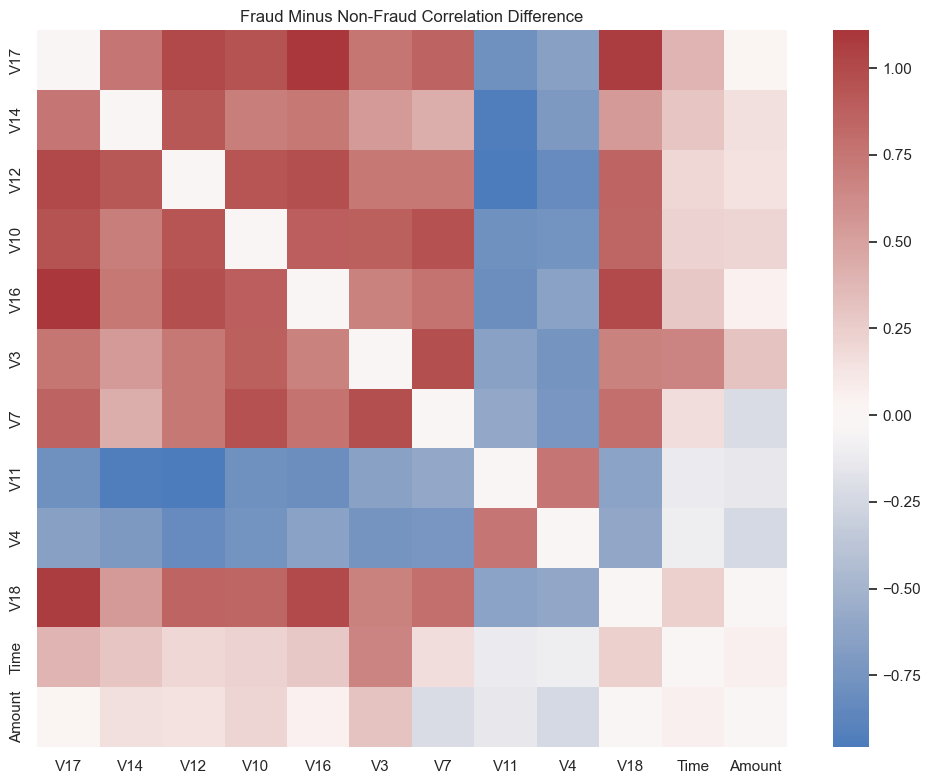

In [9]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_difference, cmap="vlag", center=0)
plt.title("Fraud Minus Non-Fraud Correlation Difference")
plt.tight_layout()
plt.savefig(NOTEBOOK_FIGURES_DIR / "correlation_difference_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


## 7. Interaction View of Strongest Features

The interaction plots below use the strongest priority features from the bivariate stage. A sampled view is used to keep the legitimate class readable while preserving all fraud cases.


In [10]:
top_3_features = selected_pca_features[:3]
class_0_sample = df.loc[df[TARGET_COLUMN] == 0].sample(n=min(5000, (df[TARGET_COLUMN] == 0).sum()), random_state=42)
class_1_all = df.loc[df[TARGET_COLUMN] == 1]
plot_df = pd.concat([class_0_sample, class_1_all], axis=0)

interaction_summary = pd.DataFrame({
    "top_feature_rank": [1, 2, 3],
    "feature": top_3_features,
    "correlation_with_class": [pca_correlations[f] for f in top_3_features],
})
interaction_summary.to_csv(NOTEBOOK_TABLES_DIR / "top_feature_interaction_summary.csv", index=False)
interaction_summary


,top_feature_rank,feature,correlation_with_class
0,1,V17,-0.313498
1,2,V14,-0.293375
2,3,V12,-0.250711


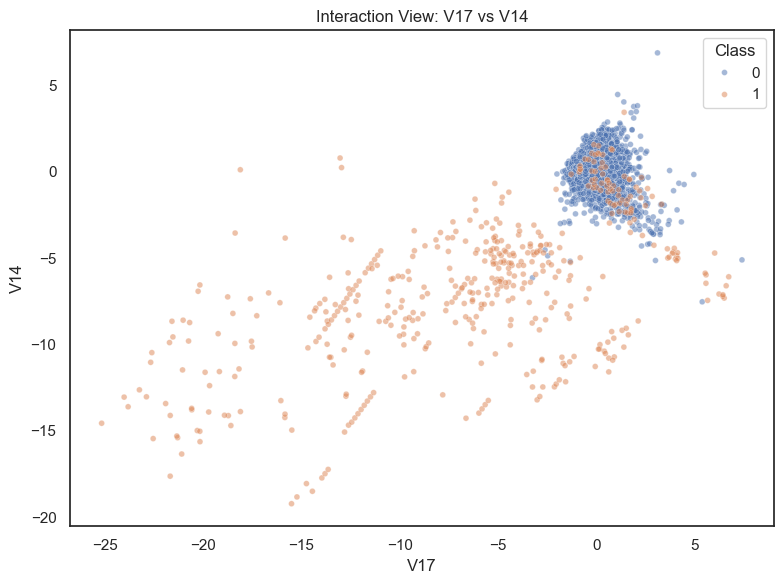

In [11]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x=top_3_features[0], y=top_3_features[1], hue=TARGET_COLUMN, alpha=0.5, s=18)
plt.title(f"Interaction View: {top_3_features[0]} vs {top_3_features[1]}")
plt.tight_layout()
plt.savefig(NOTEBOOK_FIGURES_DIR / f"{top_3_features[0].lower()}_{top_3_features[1].lower()}_interaction.png", dpi=300, bbox_inches="tight")
plt.show()


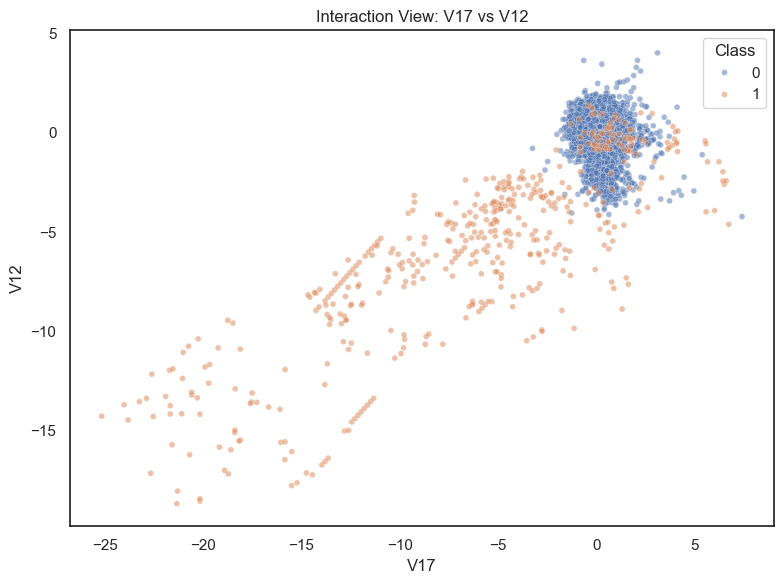

In [12]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x=top_3_features[0], y=top_3_features[2], hue=TARGET_COLUMN, alpha=0.5, s=18)
plt.title(f"Interaction View: {top_3_features[0]} vs {top_3_features[2]}")
plt.tight_layout()
plt.savefig(NOTEBOOK_FIGURES_DIR / f"{top_3_features[0].lower()}_{top_3_features[2].lower()}_interaction.png", dpi=300, bbox_inches="tight")
plt.show()


## 8. Multivariate Interpretation

- The shortlisted PCA variables should be treated as the core multivariate feature set because they carry the strongest direct signal from the bivariate stage.
- Low pairwise correlation among the selected PCA features would support keeping multiple components in the same model without severe redundancy.
- Differences between fraud and non-fraud correlation structure may indicate that fraud is characterized not only by unusual values, but also by unusual feature interactions.
- `Amount` and `Time` remain useful as contextual variables, but they are unlikely to dominate model performance without transformation or interaction-based feature engineering.


## 9. Impact on Modeling

- Linear models such as logistic regression can benefit from the low-collinearity PCA features, especially if the strongest components remain stable in the multivariate view.
- Tree-based models remain suitable because they can capture non-linear boundaries and interaction effects that may not appear in pairwise summaries alone.
- `Amount` should continue to be used in transformed form when appropriate, while `Time` may become more useful through derived features rather than raw inclusion alone.
- The multivariate stage should be used to finalize which features move forward unchanged, which need engineering, and which can be deprioritized.


## 10. Key Insights

- `V17`, `V14`, `V12`, `V10`, `V16`, `V3`, `V7`, `V11`, `V4`, and `V18` form the main multivariate candidate set from the bivariate stage.
- The multivariate correlation matrix should confirm whether these features remain complementary rather than redundant.
- Class-specific correlation differences can reveal fraud-specific interaction structure that is not visible in single-feature analysis.
- `Amount` and `Time` remain part of the analysis as contextual inputs, but they still depend on transformation or combination to add stronger predictive value.
- These findings should directly support feature engineering and model-building decisions in the next project stage.


## 11. Next Step

The next notebook should be `08_feature_engineering.ipynb`. It should transform the strongest multivariate features into an implementation-ready feature set by finalizing preprocessing decisions, creating any useful derived variables, and preparing the dataset for model training.


In [ ]:
multivariate_report = f"""# Multivariate Analysis Report

## Key Findings

- The multivariate notebook focuses on the strongest bivariate signals plus `Amount` and `Time` as contextual variables.
- The main objective is to confirm whether the shortlisted features remain useful together or become redundant when analyzed jointly.
- Fraud and non-fraud transactions may show different correlation structure even when single-feature summaries look similar.

## Multivariate Interpretation

- The shortlisted PCA variables should be treated as the core multivariate feature set because they carry the strongest direct signal from the bivariate stage.
- Low pairwise correlation among the selected PCA features would support keeping multiple components in the same model without severe redundancy.
- Differences between fraud and non-fraud correlation structure may indicate that fraud is characterized not only by unusual values, but also by unusual feature interactions.
- `Amount` and `Time` remain useful as contextual variables, but they are unlikely to dominate model performance without transformation or interaction-based feature engineering.

## Impact on Modeling

- Linear models such as logistic regression can benefit from the low-collinearity PCA features, especially if the strongest components remain stable in the multivariate view.
- Tree-based models remain suitable because they can capture non-linear boundaries and interaction effects that may not appear in pairwise summaries alone.
- `Amount` should continue to be used in transformed form when appropriate, while `Time` may become more useful through derived features rather than raw inclusion alone.
- The multivariate stage should be used to finalize which features move forward unchanged, which need engineering, and which can be deprioritized.

## Key Insights

- `V17`, `V14`, `V12`, `V10`, `V16`, `V3`, `V7`, `V11`, `V4`, and `V18` form the main multivariate candidate set from the bivariate stage.
- The multivariate correlation matrix should confirm whether these features remain complementary rather than redundant.
- Class-specific correlation differences can reveal fraud-specific interaction structure that is not visible in single-feature analysis.
- `Amount` and `Time` remain part of the analysis as contextual inputs, but they still depend on transformation or combination to add stronger predictive value.
- These findings should directly support feature engineering and model-building decisions in the next project stage.

## Saved Tables

- `reports/tables/07_multivariate_analysis/selected_feature_set.csv`
- `reports/tables/07_multivariate_analysis/multivariate_correlation_matrix.csv`
- `reports/tables/07_multivariate_analysis/high_correlation_pairs.csv`
- `reports/tables/07_multivariate_analysis/class_0_correlation_matrix.csv`
- `reports/tables/07_multivariate_analysis/class_1_correlation_matrix.csv`
- `reports/tables/07_multivariate_analysis/correlation_difference_matrix.csv`
- `reports/tables/07_multivariate_analysis/top_feature_interaction_summary.csv`
- `reports/tables/07_multivariate_analysis/multivariate_report.md`

## Saved Figures

- `reports/figures/07_multivariate_analysis/priority_feature_correlation_heatmap.png`
- `reports/figures/07_multivariate_analysis/class_specific_correlation_heatmaps.png`
- `reports/figures/07_multivariate_analysis/correlation_difference_heatmap.png`
- `reports/figures/07_multivariate_analysis/{top_3_features[0].lower()}_{top_3_features[1].lower()}_interaction.png`
- `reports/figures/07_multivariate_analysis/{top_3_features[0].lower()}_{top_3_features[2].lower()}_interaction.png`
"""

report_path = NOTEBOOK_TABLES_DIR / "multivariate_report.md"
report_path.write_text(multivariate_report, encoding="utf-8")
print(f"Multivariate report saved to: {report_path}")
